In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [ ]:
from variable_print import p,ps,pst

# REINFORCE Algorithm 구현 2

In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp
import keras
from keras.layers import Dense,Input
from keras.models import Sequential
from keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Environment : CartPole 생성

In [ ]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(gym.__version__)  #1.2.0
print("="*10)
print('State space: ', env.observation_space)
print('Action space: ', env.action_space)
print("="*10)
s_dim = env.observation_space.shape[0]
a_dim = env.action_space.n
print(f"State dimension: {s_dim}")
print(f"Action dimension: {a_dim}")

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)
State dimension: 4
Action dimension: 2


## Neural Network 만들기  

In [ ]:
def NeuralNetwork(state_size=4, action_size=2, hidden_size=30, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(state_size,)))
    model.add(Dense(hidden_size, activation='relu'))
    model.add(Dense(hidden_size, activation='relu'))
    model.add(Dense(action_size, activation='softmax'))
    return model

In [ ]:
net = NeuralNetwork()
net.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            62 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142 (4.46 KB)

 Trainable params: 1,142 (4.46 KB)

 Non-trainable params: 0 (0.00 B)

## REINFORCE Agent 만들기   
### Episode단위로 학습 하기


### Memory handling 준비
```python
# sample(st,at,rt,st+1,done)을 저장해주고 리턴을 계산
memory = EpisodicMemory(max_size=100, gamma=1.0)
```

### Trajectory를 받아서 저장, done을 만나면 return값을 계산해서 보관  

```python
class Trajectory:
    def __init__(self, gamma: float):
        self.states = list()
        ...
        self.dones = list()
    def push(self, state, action, reward, next_state, done):
        self.states.append(state)
        ...
        self.dones.append(done)
        if done: self.compute_return()

    def compute_return(self): # return 계산
        for r in rewards[::-1]:
            g = r + self.gamma * g
            ...
        self.returns = returns

    def get_samples(self):
        states = np.array(self.states)    # na.array() <- list()
        ...
        returns = np.array(self.returns)
        return states, actions,rewards,next_states, dones, returns
```         

In [ ]:
class Trajectory:

    def __init__(self, gamma: float):
        self.gamma = gamma
        self.states = list()
        self.actions = list()
        self.rewards = list()
        self.next_states = list()
        self.dones = list()

        self.length = 0
        self.returns = None
        self._discounted = False

    def push(self, state, action, reward, next_state, done):
        if done and self._discounted:
            raise RuntimeError("done is given at least two times!")

        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.next_states.append(next_state)
        self.dones.append(done)
        self.length += 1

        if done and not self._discounted:
            # compute returns
            self.compute_return()

    def compute_return(self):
        rewards = self.rewards
        returns = list()
        g = 0
        # iterating returns in reverse order
        for r in rewards[::-1]:
            g = r + self.gamma * g
            returns.insert(0, g)
        self.returns = returns
        self._discounted = True

    def get_samples(self):
        states = np.array(self.states)    # na.array() <- list()
        actions = np.array(self.actions)  # (steps,)
        rewards = np.array(self.rewards)
        next_states = np.array(self.next_states)
        dones = np.array(self.dones)
        returns = np.array(self.returns)
        return states, actions,rewards,next_states, dones, returns


### Queue에 Trajectory단위로 push / pop

```python
# deque : 양쪽 방향에서 element 추가, 제거 가능 # queue : FIFO
from collections import deque
class EpisodicMemory:
    def __init__(self, max_size: int, gamma: float):
        ...
        self.trajectories = deque(maxlen=max_size) #trajectory들을 저장
        self._trajectory = Trajectory(gamma=gamma)
    def push(self, state, action, reward, next_state, done):
        self._trajectory.push(state, action, reward, next_state, done)
        if done: #episode가 끝나면 전체 trajectory 저장
            self.trajectories.append(self._trajectory)
    def reset(self):
        ...
    def get_samples(self):
        while self.trajectories:       # trajecory들을 모두 꺼내어 분해, 조립
            traj = self.trajectories.pop() # 하나의 Traj. 가져오고  
            s, a, r, ns, done, g = traj.get_samples()# trajectory 분해
            states.append(s)               #모든 traj.의 states 모음
            ...
            returns.append(g)
        
        states = np.concatenate(states)    # (epi.*steps,s) <- [(steps,s),...]
        ...
        returns = np.concatenate(returns)  # (epi.*steps, ) <- [(steps,),...]

        return states, actions, rewards, next_states, dones, returns
```        

In [ ]:
# queue : FIFO
# deque : 양쪽 방향에서 element 추가, 제거 가능
from collections import deque

class EpisodicMemory:

    def __init__(self, max_size: int, gamma: float):
        self.max_size = max_size  # maximum number of trajectories
        self.gamma = gamma
        self.trajectories = deque(maxlen=max_size) #trajectory들을 저장
        self._trajectory = Trajectory(gamma=gamma)

    def push(self, state, action, reward, next_state, done):
        self._trajectory.push(state, action, reward, next_state, done)
        if done: #episode가 끝나면 전체 trajectory 저장
            self.trajectories.append(self._trajectory)
            self._trajectory = Trajectory(gamma=self.gamma) # 임시 trajectory

    def reset(self):
        self.trajectories.clear()
        self._trajectory = Trajectory(gamma=self.gamma)

    def get_samples(self):
        states,actions,rewards,next_states,dones,returns = [],[],[],[],[],[]
        while self.trajectories:           # trajecory들을 모두 꺼내어 분해, 조립
            traj = self.trajectories.pop() # 하나의 Traj. 가져오고
            s, a, r, ns, done, g = traj.get_samples()# trajectory 분해
            states.append(s)               #모든 traj.의 states 모음
            actions.append(a)
            rewards.append(r)
            next_states.append(ns)
            dones.append(done)
            returns.append(g)

        states = np.concatenate(states)    # (steps,s) <- [(s,),(s,),...]
        actions = np.concatenate(actions)  # (steps,)
        rewards = np.concatenate(rewards)  # (steps,)
        next_states = np.concatenate(next_states)
        dones = np.concatenate(dones)
        returns = np.concatenate(returns)
        return states, actions, rewards, next_states, dones, returns

### REINFORCE Agent 수정


In [ ]:
class REINFORCE:
    def __init__(self, policy_model,
#                 gamma = 1.0, lr = 0.001):
                 gamma = 1.0, lr = 0.01):

        super(REINFORCE, self).__init__()
        self.model = policy_model
        self.gamma = gamma
        self.optimizer = Adam(learning_rate=lr) # NN optimizer
        self._eps = 1e-25

    def get_action(self, state): # action <- sampling(model(state))
        prob_a = self.model.predict(state, batch_size=1,verbose=0).flatten()
        return np.random.choice(2, 1, p=prob_a)[0] #p(left, right)에서 sampling

    def _pre_process_inputs(self,episode):# epi. trejectory를 역순으로 재배치
        states, actions, rewards = episode
        states = np.flip(states,axis=0) #(steps,s)
        actions = np.flip(actions)      #(steps,)
        rewards = np.flip(rewards)      #(steps,)
        return states, actions, rewards

    # def loss(self, prob_a, action, gt):
    #     dist = tfp.distributions.Categorical(probs=prob_a, dtype=tf.float32)
    #     log_prob = dist.log_prob(action) # prob_a=[0.3,0.7], action=1
    #     loss = -log_prob * gt            # -log(prob_a[action])*gt
    #     return loss

    def loss(self, prob_a, action, gt):
        log_probability = tf.math.log(prob_a[0][action] + self._eps)
        loss = -log_probability * gt
        return loss

    # sample-by-sample update version of REINFORCE
    @tf.function
    def update(self, episode):
        ## _pre_process_inputs: trajectory 순서 뒤집기,뒤부터 gamma적용하기 위해
        states, actions, rewards = self._pre_process_inputs(episode)
        g = tot_loss = cnt = 0
        for i,(s, a, r) in enumerate(zip(states, actions, rewards)): # step반복
            with tf.GradientTape() as tape:
                g = r + self.gamma * g                    # 현 setp에서 Gt 계산
                prob_a = self.model(s.reshape(1,4), training=True)#두action의 확률
                loss = self.loss(prob_a, a, g)            # -log(pi(selected_a))*Gt
            grads = tape.gradient(loss, self.model.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
            tot_loss += loss
            cnt = i+1
        return tot_loss/cnt

    ## episodes ## batch update version of REINFORCE
    def update_episodes(self, states, actions, returns, use_norm=True):
        if use_norm:  ## return값 Normalization
            returns = (returns - returns.mean())/(returns.std()+self._eps)
        with tf.GradientTape() as tape:
            prob_a = self.model(states.reshape(-1,4), training=True) #(steps,2)
            losses = self.loss(prob_a, actions, returns)             #(steps,)
            loss = tf.math.reduce_mean(losses)                       # sclar
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss

## Training

In [ ]:
model_path = path+"models/DRL/reinforce_cartpole_norm.keras"

In [ ]:
memory = EpisodicMemory(max_size=500, gamma=1.0)

In [ ]:
%%time
net = NeuralNetwork(state_size=s_dim, action_size=a_dim)
agent = REINFORCE(net)
memory.reset()

print_every = 1
update_every = 2 # Update episodes

scores = [0]
mean_r = 0
max_score = 0

n_eps = 5*update_every # 150*update_every ########
for ep in range(n_eps): # episode 반복
    s, _ = env.reset()     # evn. 초기화
    cum_r = 0           # epi.내에서 reward sum
    # states = []
    # actions = []
    # rewards = []
    while True:         # 하나의 episode 시행
        s = np.reshape(s, (1, 4))       # (bs,s)
        a = agent.get_action(s)         # plocy net. 출력에서 sampling한 action
        ns, r, done, info, _ = env.step(a) # env. feedback
        memory.push(s,a,r,ns,done)
        s = ns                          # state update
        cum_r += r                      # epi. 길이 (epi.score)
        if done: break                  # Termination
    if ep % update_every == 0:
        s,a, _, _, done, g = memory.get_samples()
        # loss = agent.update_episodes(s, a, g) # use_norm=True
        loss = agent.update_episodes(s, a, g, use_norm=True)
        scores.append(cum_r)
        mean_score = np.mean(scores[-10:])
        print(f"Epi./Iter. {ep}/{ep//update_every} || mean_score: {mean_score:.1f} ||  Loss: {loss:.6f} ")
    if mean_score > max_score :
        max_score = mean_score
        agent.model.save(model_path)
        print(f"  model saved..")
    if max_score > 300 :
        print("목표 점수에 도달하여 학습을 조기 종료합니다.")
        agent.model.save(model_path)
        break
print("학습 종료!")

Epi./Iter. 0/0 || mean_score: 6.0 ||  Loss: -0.000169 
  model saved..
Epi./Iter. 2/1 || mean_score: 7.3 ||  Loss: 0.032722 
  model saved..
Epi./Iter. 4/2 || mean_score: 18.2 ||  Loss: 0.026875 
  model saved..
Epi./Iter. 6/3 || mean_score: 16.8 ||  Loss: 0.010773 
Epi./Iter. 8/4 || mean_score: 23.3 ||  Loss: 0.004466 
  model saved..
학습 종료!
CPU times: user 15.3 s, sys: 828 ms, total: 16.2 s
Wall time: 17.7 s


In [ ]:
%%time
net = NeuralNetwork(state_size=s_dim, action_size=a_dim)
agent = REINFORCE(net)
memory.reset()

print_every = 1
update_every = 2 # Update episodes
n_eps = 150*update_every

scores = [0]
mean_r = 0
max_score = 0

for ep in range(n_eps): # episode 반복
    s, _ = env.reset()  # evn. 초기화
    cum_r = 0           # epi.내에서 reward sum
    while True:         # 하나의 episode 시행
        s = np.reshape(s, (1, 4))       # (bs,s)
        a = agent.get_action(s)         # plocy net. 출력에서 sampling한 action
        ns, r, done, info, _ = env.step(a) # env. feedback
        memory.push(s,a,r,ns,done)
        s = ns                          # state update
        cum_r += r                      # epi. 길이 (epi.score)
        if done: break                  # Termination
    scores.append(cum_r)
    if ep % update_every == 0:
        s,a, _, _, done, g = memory.get_samples()
        # loss = agent.update_episodes(s, a, g) # use_norm=True
        loss = agent.update_episodes(s, a, g, use_norm=True)
        mean_score = np.mean(scores[-10:])
        print(f"Epi./Iter. {ep}/{ep//update_every} || mean_score: {mean_score:.1f} ||  Loss: {loss:.6f} ")
    if mean_score > max_score and len(scores) > 10:
        max_score = mean_score
        agent.model.save(model_path)
        print(f"  model saved..")
    if max_score > 300 :
        print("목표 점수에 도달하여 학습을 조기 종료합니다.")
        agent.model.save(model_path)
        break
print("학습 종료!")

# Wall time: 37min 59s

Epi./Iter. 0/0 || mean_score: 17.5 ||  Loss: -0.039318 
Epi./Iter. 2/1 || mean_score: 26.0 ||  Loss: -0.008651 
Epi./Iter. 4/2 || mean_score: 23.2 ||  Loss: -0.010509 
Epi./Iter. 6/3 || mean_score: 25.2 ||  Loss: -0.017895 
Epi./Iter. 8/4 || mean_score: 31.5 ||  Loss: -0.019347 
  model saved..
Epi./Iter. 10/5 || mean_score: 39.7 ||  Loss: -0.008132 
  model saved..
Epi./Iter. 12/6 || mean_score: 43.2 ||  Loss: -0.026473 
  model saved..
Epi./Iter. 14/7 || mean_score: 43.9 ||  Loss: 0.033775 
  model saved..
Epi./Iter. 16/8 || mean_score: 44.6 ||  Loss: -0.045178 
  model saved..
Epi./Iter. 18/9 || mean_score: 40.0 ||  Loss: -0.004483 
Epi./Iter. 20/10 || mean_score: 38.2 ||  Loss: -0.028458 
Epi./Iter. 22/11 || mean_score: 43.3 ||  Loss: -0.014174 
Epi./Iter. 24/12 || mean_score: 52.0 ||  Loss: 0.021919 
  model saved..
Epi./Iter. 26/13 || mean_score: 58.2 ||  Loss: -0.048421 
  model saved..
Epi./Iter. 28/14 || mean_score: 64.7 ||  Loss: 0.010930 
  model saved..
Epi./Iter. 30/15 || 

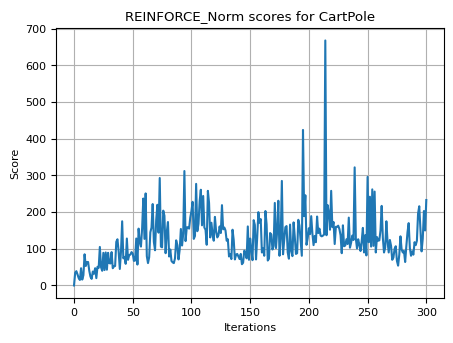

In [ ]:
def plot_moving_avg(data, window_size):
    if not data: return
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plot_moving_avg(scores,5)
plt.title('REINFORCE_Norm scores for CartPole')
plt.ylabel('Score')
plt.xlabel('Iterations')
plt.grid()
plt.show()

**Normalize 사용으로 변동성 감소**  
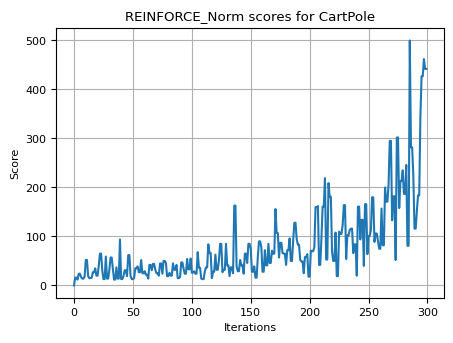

In [ ]:
#net.save(path+"models/DRL/cartpole_by_REINFORCE_Norm.keras")
#net = keras.models.load_model(path+"models/DRL/cartpole_by_REINFORCE_Norm.keras")

## Evaluation

In [ ]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
video_prefix = "REINFORCE_Norm"
env_v = wrap_env(env, path=path, name_prefix=video_prefix)

/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


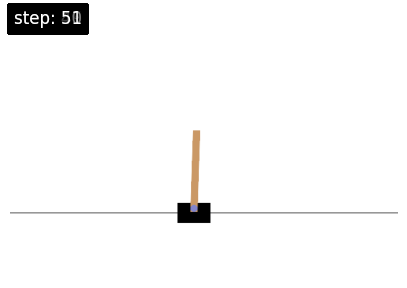

In [ ]:
state, _ = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict = net.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info,_ = env_v.step(action)
    if done or cnt > 50 :  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path, name_prefix=video_prefix)

/content/gdrive/MyDrive/Colab Notebooks/video/REINFORCE_Norm_r-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='REINFORCE_Norm')

/content/gdrive/MyDrive/Colab Notebooks/video/REINFORCE_Norm-episode-0.mp4


# 실습 과제  
## 결과를 더 개선 해 보자   
## 1) update_every = 1 로 수정하고,
## 2) episode당 학습 횟수를 늘리면 어떠게 될까?
## 3) Return Normalization의 효과를 확인해 보자  

